In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn import naive_bayes
from sklearn import metrics
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
iris = load_iris()
is_versicolor = iris.target == 1
(iris_1c_train_ftrs, iris_1c_test_ftrs, iris_1c_train_tgt, iris_1c_test_tgt) = train_test_split(iris.data, is_versicolor, test_size=.33, random_state = 21)
# build, fit, predict (probability scores) for NB model
gnb = naive_bayes.GaussianNB()
gnb.fit(iris_1c_train_ftrs, iris_1c_train_tgt)
predictions_probability = gnb.predict_proba(iris_1c_test_ftrs)
prob_true = (predictions_probability[:, 1]) # [:, 1]=="True"
print(prob_true)

[9.79865278e-01 4.50222228e-13 2.43026500e-16 1.96134602e-14
 9.52724313e-01 9.27725695e-01 3.87639359e-15 9.08785560e-03
 6.25366254e-13 2.86846833e-16 8.56437615e-01 9.58804822e-01
 1.80885105e-09 2.30342507e-14 7.70249873e-11 2.63886933e-01
 2.35755590e-01 9.61031568e-01 4.93114034e-20 4.99637540e-02
 3.19020482e-01 8.89388199e-01 7.87938780e-01 9.65605388e-01
 1.77131933e-17 3.93653599e-01 3.83266628e-16 1.66566751e-14
 9.79533423e-01 1.44515245e-06 5.14903222e-15 2.87187505e-11
 1.06081289e-01 2.48727276e-17 3.48004665e-01 9.37375446e-01
 3.94941566e-01 4.69745755e-08 4.67316571e-17 4.99637540e-02
 1.15989808e-01 2.20299432e-10 1.02490253e-02 9.71297885e-01
 1.50873250e-07 2.25970036e-17 2.59459411e-19 5.75243418e-20
 9.58230930e-01 4.68228921e-16]


FPR : [0.         0.         0.         0.06060606 0.06060606 0.12121212
 0.12121212 0.18181818 1.        ]
TPR : [0.         0.05882353 0.88235294 0.88235294 0.94117647 0.94117647
 1.         1.         1.        ]
[           inf 9.79865278e-01 3.93653599e-01 3.19020482e-01
 2.63886933e-01 1.15989808e-01 1.06081289e-01 4.99637540e-02
 4.93114034e-20]


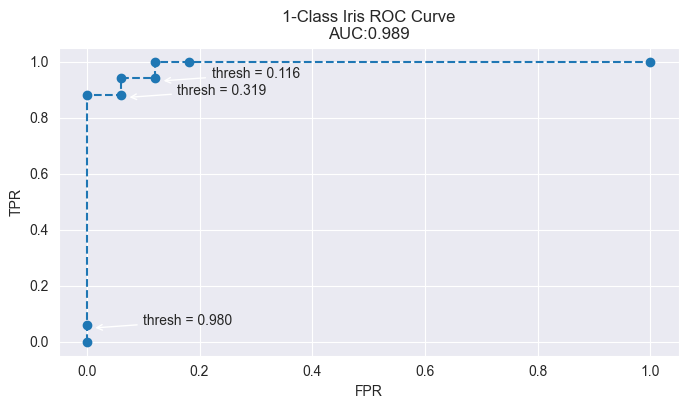

In [7]:
fpr, tpr, thresh = metrics.roc_curve(iris_1c_test_tgt, prob_true)
auc = metrics.auc(fpr, tpr)
print("FPR : {}".format(fpr), "TPR : {}".format(tpr), sep='\n')
print(thresh)

# glavni graf
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(fpr, tpr, 'o--')
ax.set_title("1-Class Iris ROC Curve\nAUC:{:.3f}".format(auc))
ax.set_xlabel("FPR")
ax.set_ylabel("TPR");

# oznacavanje tocaka
investigate = np.array([1, 3, 5])
for idx in investigate:
  th, f, t = thresh[idx], fpr[idx], tpr[idx]
  ax.annotate('thresh = {:.3f}'.format(th),
    xy=(f+.01, t-.01), xytext=(f+.1, t),
    arrowprops = {'arrowstyle':'->'})

Text(120.72222222222221, 0.5, 'Actual')

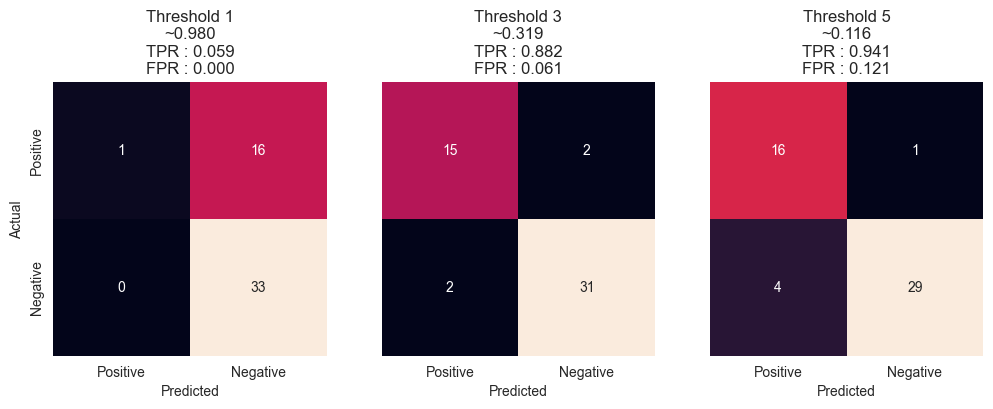

In [10]:
title_fmt = "Threshold {}\n~{:5.3f}\nTPR : {:.3f}\nFPR : {:.3f}"
pn = ['Positive', 'Negative']
add_args = {'xticklabels': pn,'yticklabels': pn, 'square':True}
fig, axes = plt.subplots(1, 3, sharey = True, figsize=(12, 4))
for ax, thresh_idx in zip(axes.flat, investigate):
  preds_at_th = prob_true < thresh[thresh_idx]
  cm = metrics.confusion_matrix(1-iris_1c_test_tgt, preds_at_th)
  sns.heatmap(cm, annot=True, cbar=False, ax=ax, **add_args)
  ax.set_xlabel('Predicted')
  ax.set_title(title_fmt.format(thresh_idx,
  thresh[thresh_idx],
  tpr[thresh_idx],
  fpr[thresh_idx]))
axes[0].set_ylabel('Actual')